# PERGUNTA 6

# Porte da empresa e salário.

Importando as Blibliotecas **pandas, numpy e matplotlib.pylot**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Criando **FUNÇÃO** para carregar um arquivo **csv**

In [2]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

Puxando a **FUNÇÃO** através da **VARIÁVEL**, e retornando o **BANCO DE DADOS**

In [3]:
df = carregar_banco_csv(
    r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\4 - TECNICAS DE PROGRAMAÇÃO I (PY) - DE 12-05-2026 A 26-05-2026\PROJETO\salario_ciencia_dados.csv"
)
df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salario_moeda_corrente,moeda_corrente,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


# Empresas grandes (L), médias (M) ou pequenas (S) pagam mais?

Comandos para Retornar a **Média Salarial Geral** e **Média em cada porte do Tamanho da Empresa**

In [4]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por tamanho da empresa
salario_por_tamanho_empresa = df.groupby("porte_empresa")["salario_usd"].mean().round(2).sort_values()
print(salario_por_tamanho_empresa)

Média salarial geral de todos os funcionários: U$ 145560.56

porte_empresa
Small      87687.46
Large     120638.40
Medium    149659.39
Name: salario_usd, dtype: float64


Média salarial geral de todos os funcionários: U$ 145560.56



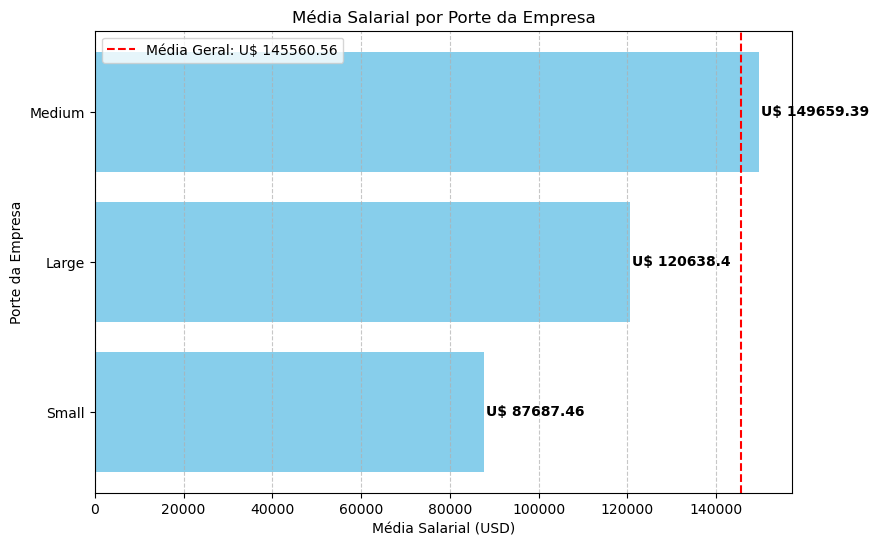

In [6]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por porte da empresa
salario_por_tamanho_empresa = df.groupby("porte_empresa")["salario_usd"].mean().round(2).sort_values()
plt.figure(figsize=(9,6))
# Barras horizontais
plt.barh(salario_por_tamanho_empresa.index, salario_por_tamanho_empresa.values, color="skyblue")
# Linha da média geral
plt.axvline(x=media_geral, color="red", linestyle="--", label=f"Média Geral: U$ {media_geral}")
# Adicionar valores nas barras
for i, v in enumerate(salario_por_tamanho_empresa.values):
    plt.text(v + 500, i, f"U$ {v}", va="center", fontweight="bold")
# Título e rótulos
plt.title("Média Salarial por Porte da Empresa")
plt.xlabel("Média Salarial (USD)")
plt.ylabel("Porte da Empresa")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# A diferença é maior em algum nível de experiência específico?

Comandos para comparação **TAMANHO x EXPERIÊNCIA.** Trazendo também o resultado da média por **TAMANHO** independente da experiência

In [7]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Média salarial por nível de experiência e tamanho da empresa
progressao_por_nivel_tamanho = df.groupby(["porte_empresa", "nivel_experiencia"])["salario_usd"].mean().unstack().round(2)
# Adicionar coluna com a média salarial do nivel
progressao_por_nivel_tamanho["media_tamanho"] = salario_por_tamanho_empresa
progressao_por_nivel_tamanho

Média salarial geral de todos os funcionários: U$ 145560.56



nivel_experiencia,Entry-level,Executive-level,Mid-level,Senior-level,media_tamanho
porte_empresa,,,,,
Large,74603.33,187993.90,100625.17,150556.66,120638.40
Medium,89223.05,190563.40,123303.99,163532.47,149659.39
Small,68485.94,169172.38,73769.65,110273.73,87687.46


Comando para Visualização em **GRÁFICO** com o resultado das variáveis calculadas

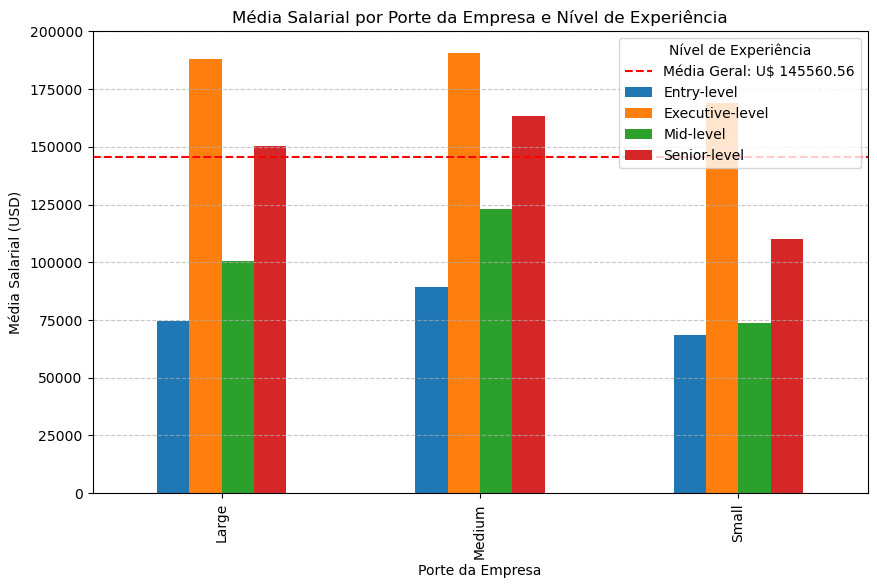

In [10]:
# Remover a coluna de média para o gráfico
df_plot = progressao_por_nivel_tamanho.drop(columns=["media_tamanho"])
# Plotar barras agrupadas
df_plot.plot(kind="bar", figsize=(10,6))
plt.axhline(y=media_geral, color="red", linestyle="--", label=f"Média Geral: U$ {media_geral}")
plt.title("Média Salarial por Porte da Empresa e Nível de Experiência")
plt.xlabel("Porte da Empresa")
plt.ylabel("Média Salarial (USD)")
plt.legend(title="Nível de Experiência")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()